6DOF Inverse Kinematics using IKPY
==================================

This is a demo of how to use IKPY to move a 6DOF robot arm.

Please don't comment and tell me how rubbish this code is, it's meant to demonstrate how easy this is to use, not to show off mad Python skills.

We'll start by importing all our libraries

In [35]:
import ikpy.chain
import ikpy.utils.plot as plot_utils

import numpy as np
import time
import math

import ipywidgets as widgets
import serial

Now, we can import our robot arm model from the URDF file. The first link is the link between the desk and the base, so we set it to inactive

In [36]:
my_chain = ikpy.chain.Chain.from_urdf_file(
    "arm_urdf.urdf",
    active_links_mask=[False, False, True, True, True, True, False]
)

And set the initial position and orientation of the last joint

In [37]:

target_position = [0.15, 0, 0.4]

target_orientation = [-1, 0, 0]

It's now just one call to work out he inverse kinematics for that position. Again, the first angle is of the inactive joint between the desk and the base so is always 0

In [38]:
ik = my_chain.inverse_kinematics(target_position)
print("The angles of each joints are : ", list(map(lambda r: math.degrees(r), ik.tolist())))

The angles of each joints are :  [0.0, 0.0, 89.01471375110988, -36.98694635764071, 89.38758015368099, 0.0, 0.0]


In [28]:
print(len(ik))

7


We can see that actual position our robot will move to. This may be different to _target_position_ as the arm may not be physically able to reach that position

In [39]:
computed_position = my_chain.forward_kinematics(ik)
print("Computed position: %s, original position : %s" % (computed_position[:3, 3], target_position))
print("Computed position (readable) : %s" % [ '%.2f' % elem for elem in computed_position[:3, 3] ])

Computed position: [0.15       0.         0.39999999], original position : [0.15, 0, 0.4]
Computed position (readable) : ['0.15', '0.00', '0.40']


Now, lets visualise what our arm looks

[0.15, 0, 0.4]


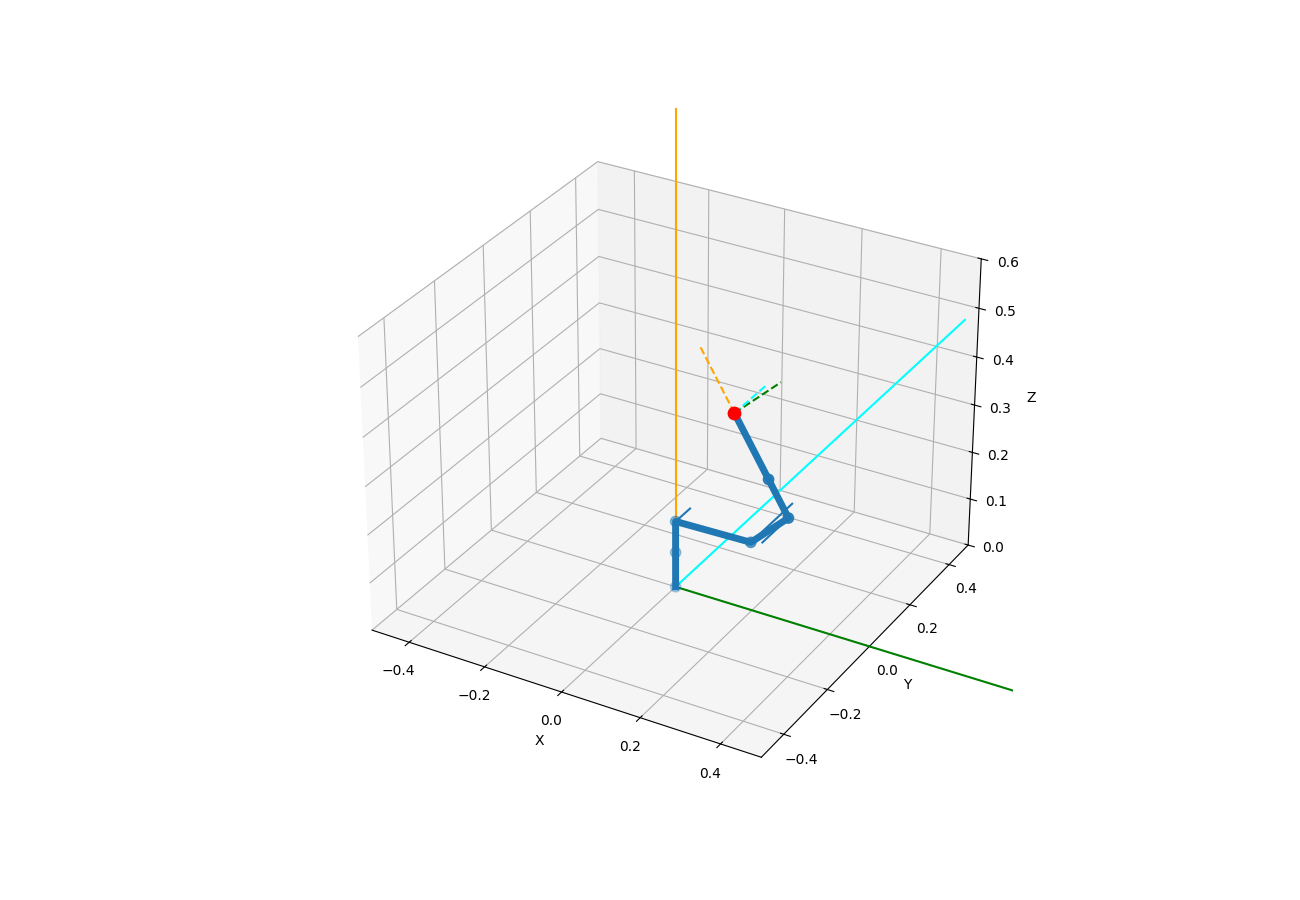

In [40]:
%matplotlib widget
#%matplotlib widget
import matplotlib.pyplot as plt
fig, ax = plot_utils.init_3d_figure()
fig.set_figheight(9)
fig.set_figwidth(13)
my_chain.plot(ik, ax, target=target_position)
print(target_position)
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
ax.set_zlim(0, 0.6)
plt.ion()

Joint positions:
  0: Base → base_rot            (0.000, 0.000, 0.000)
  1: base_rot → shoulder        (0.000, 0.000, 0.074)
  2: arm1 (upper arm)           (0.000, 0.000, 0.140)
  3: arm2 (forearm)             (0.195, 0.000, 0.143)
  4: wrist                      (0.290, 0.000, 0.217)
  5: gripper                    (0.238, 0.000, 0.285)
  end effector:              (0.150, 0.000, 0.400)


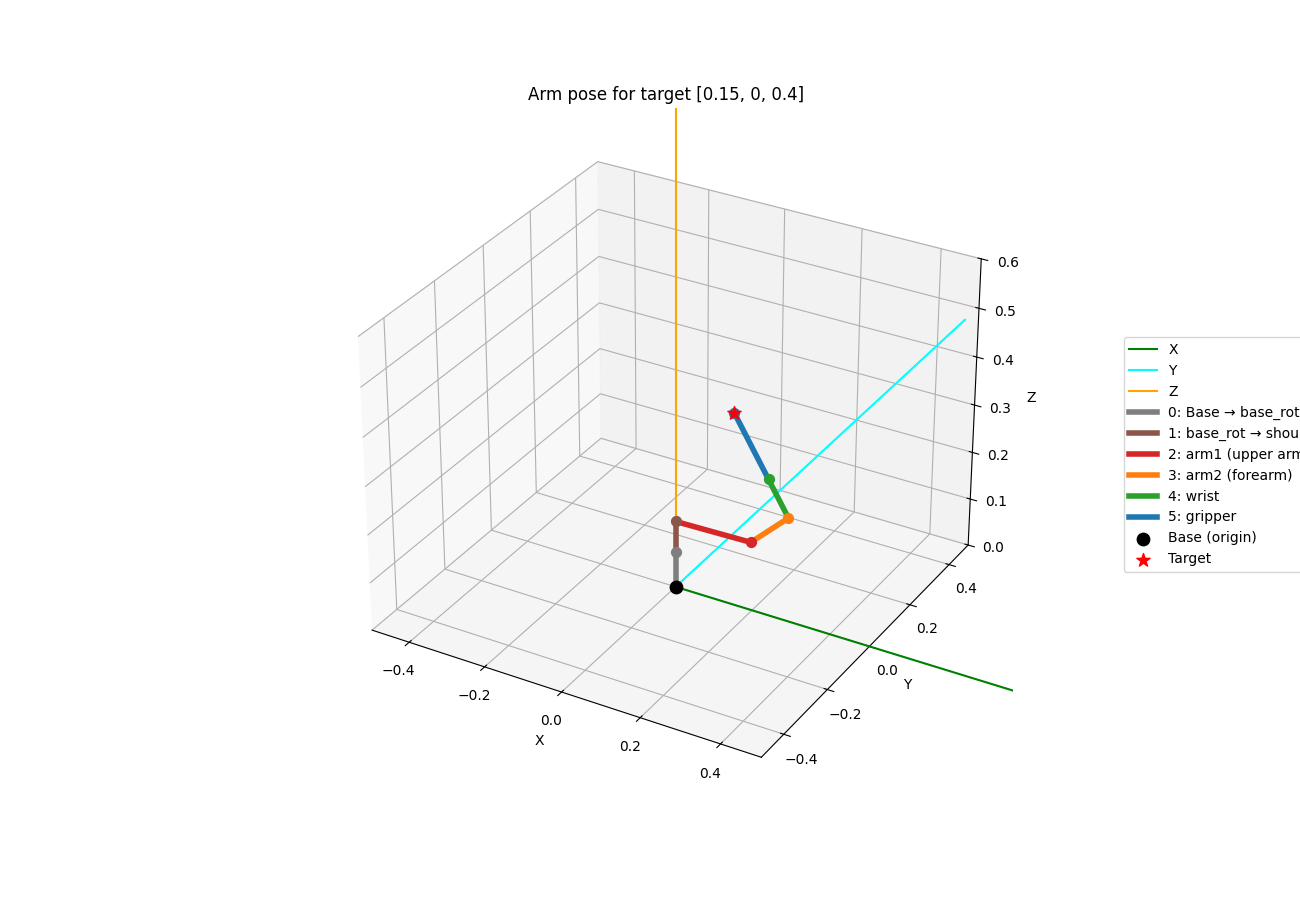

In [41]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plot_utils.init_3d_figure()
fig.set_figheight(9)
fig.set_figwidth(13)

# Compute position of every joint along the chain
# forward_kinematics(ik, full_kinematics=True) returns a transformation matrix
# for each link; we just want the translation part (the x,y,z position)
frames = my_chain.forward_kinematics(ik, full_kinematics=True)
positions = np.array([f[:3, 3] for f in frames])

# Define colors and names for each segment
# Each segment goes from positions[i] to positions[i+1]
segment_info = [
    ("Base → base_rot",    "tab:gray"),
    ("base_rot → shoulder", "tab:brown"),
    ("arm1 (upper arm)",    "tab:red"),
    ("arm2 (forearm)",      "tab:orange"),
    ("wrist",               "tab:green"),
    ("gripper",             "tab:blue"),
]

# Draw each segment individually with its own color
for i, (name, color) in enumerate(segment_info):
    if i + 1 >= len(positions):
        break
    p0 = positions[i]
    p1 = positions[i + 1]
    ax.plot(
        [p0[0], p1[0]],
        [p0[1], p1[1]],
        [p0[2], p1[2]],
        color=color,
        linewidth=4,
        label=f"{i}: {name}"
    )
    # Mark each joint with a dot
    ax.scatter(*p1, color=color, s=50)

# Mark the base
ax.scatter(*positions[0], color="black", s=80, label="Base (origin)")

# Plot the target
ax.scatter(*target_position, color="red", s=100, label="Target", marker="*")

# Legend outside the plot
ax.legend(loc="center left", bbox_to_anchor=(1.15, 0.5), fontsize=10)

plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
ax.set_zlim(0, 0.6)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title(f"Arm pose for target {target_position}")

# Print the joint positions too
print("Joint positions:")
for i, (name, _) in enumerate(segment_info):
    if i < len(positions):
        p = positions[i]
        print(f"  {i}: {name:25s}  ({p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f})")
if len(positions) > len(segment_info):
    p = positions[-1]
    print(f"  end effector:              ({p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f})")

In [42]:
print(len(my_chain.links))
for i, link in enumerate(my_chain.links):
    print(i, link.name)

7
0 Base link
1 base_joint
2 shoulder_joint
3 elbow_joint
4 wrist_joint
5 wrist_rot_joint
6 tool_joint


Let's now make wrap up some of these calls into a couple of functions. Calling _move(x,y,z)_ will move us to the new coordinates and update the plot.

It's worth noting here that when we call _inverse_kinematcs_, we pass in the old position (joint angles) as _initial_position_ so IKPY find the nearest solution to our current position.

In [43]:
def doIK():
    global ik
    old_position = ik.copy()
    ik = my_chain.inverse_kinematics(
        target_position,
        initial_position=old_position
    )

def updatePlot():
    ax.clear()
    my_chain.plot(ik, ax, target=target_position)
    plt.xlim(-0.5, 0.5)
    plt.ylim(-0.5, 0.5)
    ax.set_zlim(0, 0.6)
    fig.canvas.draw()
    fig.canvas.flush_events()

def move(x, y, z):
    global target_position
    target_position = [x, y, z]
    doIK()
    updatePlot()
    sendCommand(ik[2].item(), ik[3].item(), ik[4].item(), ik[5].item(), gripper=0)

We should now be able to move our visualised arm with a call to _move(x,y,z)_

In [ ]:
print("Before move:", ik)
move(0.5, 0, 0)
print("After move:", ik)
print("Target:", target_position)
print("Forward kinematics:", my_chain.forward_kinematics(ik)[:3, 3])

In [ ]:
print(len(ik))
print(my_chain.links)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_range = np.arange(-0.35, 0.36, 0.05)
z_range = np.arange(0.00, 0.56, 0.05)

reachable = []
unreachable = []

# Two starting poses: arm tilted backward, and arm tilted forward
initial_guesses = [
    np.array([0, 0, 0.5, -1.0, 0.5, 0, 0]),    # backward tilt
    np.array([0, 0, -0.5, 1.0, -0.5, 0, 0]),   # forward tilt
    np.array([0, 0, 0.8, -1.5, 0.7, 0, 0]),    # more backward tilt
    np.array([0, 0, -0.8, 1.5, -0.7, 0, 0]),   # more forward tilt
]

for x in x_range:
    for z in z_range:
        target = [float(x), 0.0, float(z)]
        found_reachable = False

        for initial in initial_guesses:
            try:
                ik_solution = my_chain.inverse_kinematics(target, initial_position=initial)
                fk = my_chain.forward_kinematics(ik_solution)[:3, 3]
                error = np.sqrt((fk[0]-x)**2 + fk[1]**2 + (fk[2]-z)**2)

                s = int(SHOULDER_SIGN  * math.degrees(ik_solution[2]) + SHOULDER_OFFSET)
                e = int(ELBOW_SIGN     * math.degrees(ik_solution[3]) + ELBOW_OFFSET)
                w = int(WRIST_SIGN     * math.degrees(ik_solution[4]) + WRIST_OFFSET)
                r = int(WRIST_ROT_SIGN * math.degrees(ik_solution[5]) + WRIST_ROT_OFFSET)
                servos_ok = all(0 <= v <= 180 for v in [s, e, w, r])

                if error < 0.01 and servos_ok:
                    reachable.append((x, z))
                    found_reachable = True
                    break
            except Exception:
                continue

        if not found_reachable:
            unreachable.append((x, z))

fig, ax = plt.subplots(figsize=(10, 8))
if reachable:
    rx, rz = zip(*reachable)
    ax.scatter(rx, rz, c='green', s=100, label=f'Reachable ({len(reachable)})', marker='s')
if unreachable:
    ux, uz = zip(*unreachable)
    ax.scatter(ux, uz, c='red', s=50, label=f'Unreachable ({len(unreachable)})', marker='x')

ax.scatter(0, 0, c='black', s=200, marker='*', label='Base origin (desk)')
ax.scatter(0, 0.122, c='blue', s=200, marker='^', label='Shoulder pivot')
ax.set_xlabel('X (metres) — forward')
ax.set_ylabel('Z (metres) — height')
ax.set_title('Reachable Workspace (trying multiple initial guesses)')
ax.grid(True)
ax.legend()
ax.set_xlim(-0.4, 0.4)
ax.set_ylim(-0.05, 0.6)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"\nReachable: {len(reachable)}, Unreachable: {len(unreachable)}")

Let's now connect to our robot arm and create a function to send the angles to it. We just have to uncomment that _sendcommand_ line in the move function to make this work

In [44]:
ser = serial.Serial('/dev/tty.usbmodem101', 9600, timeout=1)

# Calibration — from your straight-vertical test
SHOULDER_OFFSET  = 80
ELBOW_OFFSET     = 92
WRIST_OFFSET     = 80
WRIST_ROT_OFFSET = 90

SHOULDER_SIGN    = 1
ELBOW_SIGN       = 1
WRIST_SIGN       = 1
WRIST_ROT_SIGN   = 1

def sendCommand(shoulder, elbow, wrist, wrist_rot, gripper=0):
    s = int(SHOULDER_SIGN  * math.degrees(shoulder)  + SHOULDER_OFFSET)
    e = int(ELBOW_SIGN     * math.degrees(elbow)     + ELBOW_OFFSET)
    w = int(WRIST_SIGN     * math.degrees(wrist)     + WRIST_OFFSET)
    r = int(WRIST_ROT_SIGN * math.degrees(wrist_rot) + WRIST_ROT_OFFSET)
    g = int(gripper)

    command = f"ik {s} {e} {w} {r} {g}\n"
    ser.write(command.encode('ASCII'))

    print(f"Sent: {command.strip()}")

In [45]:
import numpy as np

# Pick a target we want to test
x, y, z = 0.15, 0, 0.4
target_position = [x, y, z]



# Solve IK with a non-zero initial guess
initial = np.array([0, 0, 0.5, -1.0, 0.5, 0, 0])
ik = my_chain.inverse_kinematics(target_position, initial_position=initial)

# What did IK produce?
print("=" * 50)
print(f"TARGET:  ({x}, {y}, {z}) metres")
print("=" * 50)
print("\nIK solution (radians):")
for i, link in enumerate(my_chain.links):
    print(f"  {i} {link.name:20s}  {ik[i]:+.3f} rad  ({math.degrees(ik[i]):+.1f}°)")

# Where does IKPy think the arm ends up?
fk = my_chain.forward_kinematics(ik)[:3, 3]
print(f"\nIKPy says arm will reach: ({fk[0]:+.3f}, {fk[1]:+.3f}, {fk[2]:+.3f})")
print(f"Error vs target:          ({fk[0]-x:+.3f}, {fk[1]-y:+.3f}, {fk[2]-z:+.3f})")

# What servo angles would Python send?
s = int(SHOULDER_SIGN  * math.degrees(ik[2]) + SHOULDER_OFFSET)
e = int(ELBOW_SIGN     * math.degrees(ik[3]) + ELBOW_OFFSET)
w = int(WRIST_SIGN     * math.degrees(ik[4]) + WRIST_OFFSET)
r = int(WRIST_ROT_SIGN * math.degrees(ik[5]) + WRIST_ROT_OFFSET)
print(f"\nServo angles Python will send:")
print(f"  Shoulder: {s}°   {'⚠️ CLAMPED' if s<0 or s>180 else 'OK'}")
print(f"  Elbow:    {e}°   {'⚠️ CLAMPED' if e<0 or e>180 else 'OK'}")
print(f"  Wrist:    {w}°   {'⚠️ CLAMPED' if w<0 or w>180 else 'OK'}")
print(f"  WristRot: {r}°   {'⚠️ CLAMPED' if r<0 or r>180 else 'OK'}")

move(x, y, z)


TARGET:  (0.15, 0, 0.4) metres

IK solution (radians):
  0 Base link             +0.000 rad  (+0.0°)
  1 base_joint            +0.000 rad  (+0.0°)
  2 shoulder_joint        +1.499 rad  (+85.9°)
  3 elbow_joint           -0.520 rad  (-29.8°)
  4 wrist_joint           +1.657 rad  (+94.9°)
  5 wrist_rot_joint       +0.000 rad  (+0.0°)
  6 tool_joint            +0.000 rad  (+0.0°)

IKPy says arm will reach: (+0.150, +0.000, +0.400)
Error vs target:          (-0.000, +0.000, +0.000)

Servo angles Python will send:
  Shoulder: 165°   OK
  Elbow:    62°   OK
  Wrist:    174°   OK
  WristRot: 90°   OK
Sent: ik 165 62 174 90 0


In [ ]:
x, y, z = 0.4, 0, 0.3
 #x offset +0.1 in real life ?
 #z offset -0.24 in real life?


move(x, y,z)



Sent: ik 166 89 110 90 0


In [11]:
import time
ser.reset_input_buffer()
ser.write(b'status\n')
time.sleep(1)
print(ser.read_all().decode(errors='ignore'))

------ CURRENT ANGLES ------
  Shoulder L: 157  R: 23
  Elbow:      70
  Wrist:      173
  Wrist Rot:  90
  Gripper:    0
----------------------------



In [ ]:

sendCommand(ik[2].item(), ik[3].item(), ik[4].item(), ik[5].item(), gripper=0)



In [65]:
sendCommand(0, 0, 0, 0, 0)

Sent: ik 80 92 80 90 0


In [55]:
ser.close()

But that's a bit boring, why don't we hook up a game controller and make the joysticks move the visualised arm!

In [ ]:
import ipywidgets as widgets
con = widgets.Controller()
display(con)

We'll need a task running in the background to monitor the controller and call move. Pressing the start button on the controller will end this task.

In [ ]:
import asyncio

async def main():
    x=0
    y=0.25
    z=0.1
    while con.buttons[9].value<1:
        xp=con.axes[0].value
        yp=con.axes[1].value
        zp=con.axes[2].value
        if(abs(xp)>0.1 or abs(yp)>0.1 or abs(zp)>0.1):
            x=x+xp/100
            y=y-yp/100
            z=z-zp/100
            move(x,y,z)
        await asyncio.sleep(0.05)


loop = asyncio.get_event_loop()
loop.create_task(main())

And, when we're done we can close the serial port.

In [66]:
ser.close()